# Week 4 — Interpolation & Approximation: Lagrange, Newton, Splines & Least Squares

> **Numerical Methods from Scratch** · Pure NumPy + Matplotlib

Given data points, we want a function that passes through them (**interpolation**) or one that captures the trend without overfitting (**approximation**). This week we build:

1. **Polynomial interpolation** via Lagrange and Newton divided-difference forms.
2. The **Runge phenomenon** — why high-degree interpolation on equispaced nodes is a disaster, and how **Chebyshev nodes** fix it.
3. **Cubic splines** — piecewise cubics with continuous curvature, the practical workhorse.
4. **Least-squares** polynomial fitting through the normal equations, and why that is *not* how you should actually compute it.

The deep lesson: interpolation and approximation are governed by the *placement of nodes* and the *conditioning of the basis*, not merely by the degree.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Lagrange interpolation

The unique polynomial of degree $\le n$ through $n+1$ points $(x_i, y_i)$ can be written in the **Lagrange basis**

$$ p(x) = \sum_{i=0}^{n} y_i\, \ell_i(x), \qquad \ell_i(x) = \prod_{j\neq i} \frac{x - x_j}{x_i - x_j}. $$

Each basis function $\ell_i$ is $1$ at $x_i$ and $0$ at every other node — so the interpolation property is built in. It is elegant for theory but $\mathcal{O}(n^2)$ per evaluation and awkward to update.


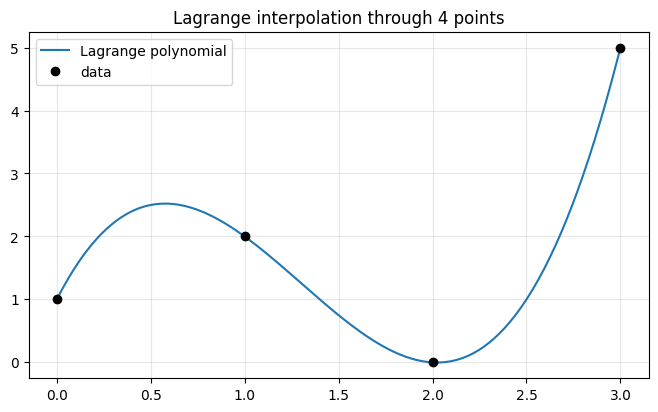

In [2]:
def lagrange_interp(xnodes, ynodes, xq):
    xq = np.atleast_1d(xq).astype(float)
    n = len(xnodes)
    result = np.zeros_like(xq)
    for i in range(n):
        Li = np.ones_like(xq)
        for j in range(n):
            if j != i:
                Li *= (xq - xnodes[j]) / (xnodes[i] - xnodes[j])
        result += ynodes[i] * Li
    return result

xnodes = np.array([0., 1., 2., 3.])
ynodes = np.array([1., 2., 0., 5.])
xq = np.linspace(0, 3, 200)
yq = lagrange_interp(xnodes, ynodes, xq)

fig, ax = plt.subplots()
ax.plot(xq, yq, label="Lagrange polynomial")
ax.plot(xnodes, ynodes, "ko", label="data")
ax.set_title("Lagrange interpolation through 4 points")
ax.legend(); plt.show()


## 2. Newton's divided differences

Newton's form builds the same polynomial incrementally, which makes *adding a new point* cheap:

$$ p(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1) + \cdots $$

The coefficients are the **divided differences** $c_k = f[x_0,\dots,x_k]$, computed by the recurrence

$$ f[x_i,\dots,x_{i+k}] = \frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}. $$

Evaluation uses **Horner-like nested multiplication** — efficient and numerically friendly.


In [3]:
def divided_differences(x, y):
    n = len(x)
    coef = y.astype(float).copy()
    for k in range(1, n):
        coef[k:] = (coef[k:] - coef[k-1:-1]) / (x[k:] - x[:-k])
    return coef                              # coef[k] = f[x0,...,xk]

def newton_eval(x, coef, xq):
    xq = np.atleast_1d(xq).astype(float)
    result = np.full_like(xq, coef[-1])
    for k in range(len(coef)-2, -1, -1):
        result = result * (xq - x[k]) + coef[k]
    return result

coef = divided_differences(xnodes, ynodes)
print("divided-difference coefficients:", coef)
yq_newton = newton_eval(xnodes, coef, xq)
print("matches Lagrange?", np.allclose(yq_newton, yq))


divided-difference coefficients: [ 1.          1.         -1.5         1.66666667]
matches Lagrange? True


Both forms produce the *same* polynomial (it is unique) — they differ only in how it is represented and evaluated.

## 3. The Runge phenomenon

It is tempting to think more nodes = better fit. For **equispaced** nodes and high degree, the opposite happens: the interpolant oscillates wildly near the endpoints. The textbook example is Runge's function $f(x) = \frac{1}{1+25x^2}$ on $[-1,1]$.


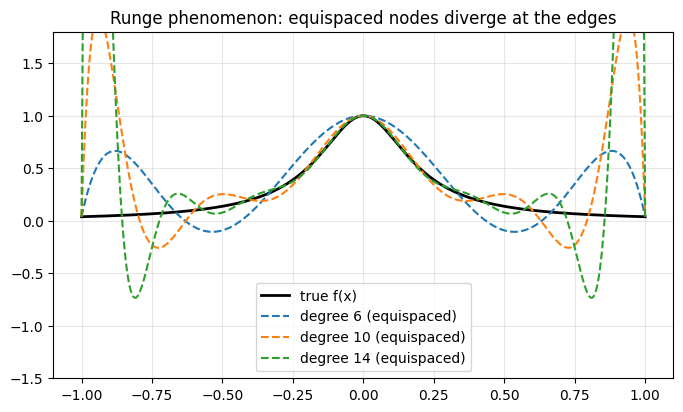

In [4]:
runge = lambda x: 1.0 / (1 + 25*x**2)
xfine = np.linspace(-1, 1, 600)

fig, ax = plt.subplots()
ax.plot(xfine, runge(xfine), "k", lw=2, label="true f(x)")
for n in [6, 10, 14]:
    xe = np.linspace(-1, 1, n+1)              # EQUISPACED nodes
    ce = divided_differences(xe, runge(xe))
    ax.plot(xfine, newton_eval(xe, ce, xfine), "--", label=f"degree {n} (equispaced)")
ax.set_ylim(-1.5, 1.8)
ax.set_title("Runge phenomenon: equispaced nodes diverge at the edges")
ax.legend(); plt.show()


### The fix: Chebyshev nodes

Cluster the nodes toward the endpoints using the **Chebyshev points**

$$ x_k = \cos\!\left(\frac{k\pi}{n}\right), \quad k=0,\dots,n. $$

This clustering tames the error growth, and the interpolant converges beautifully even at high degree.


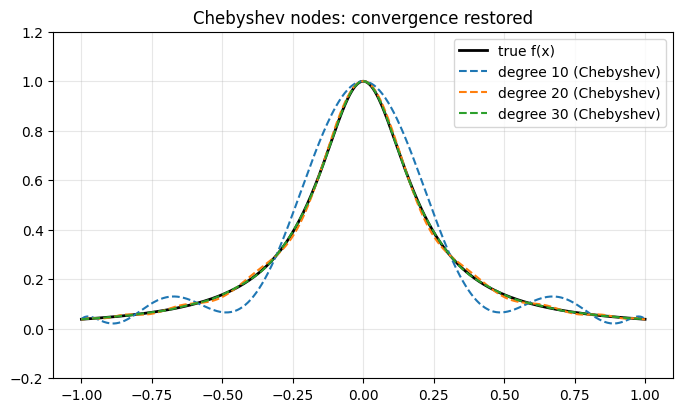

In [5]:
def chebyshev_nodes(n):
    return np.cos(np.pi * np.arange(n+1) / n)

fig, ax = plt.subplots()
ax.plot(xfine, runge(xfine), "k", lw=2, label="true f(x)")
for n in [10, 20, 30]:
    xc = chebyshev_nodes(n)
    cc = divided_differences(xc, runge(xc))
    ax.plot(xfine, newton_eval(xc, cc, xfine), "--", label=f"degree {n} (Chebyshev)")
ax.set_ylim(-0.2, 1.2)
ax.set_title("Chebyshev nodes: convergence restored")
ax.legend(); plt.show()


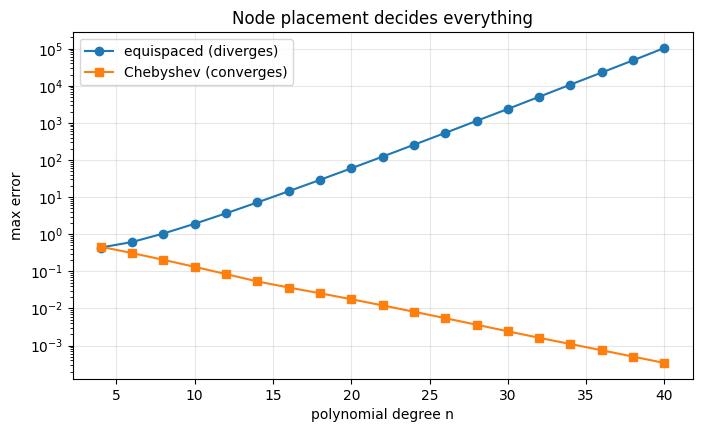

In [6]:
# Quantify: max error vs degree for the two node sets.
degrees = range(4, 41, 2)
err_equi, err_cheb = [], []
for n in degrees:
    xe = np.linspace(-1, 1, n+1)
    err_equi.append(np.max(np.abs(newton_eval(xe, divided_differences(xe, runge(xe)), xfine) - runge(xfine))))
    xc = chebyshev_nodes(n)
    err_cheb.append(np.max(np.abs(newton_eval(xc, divided_differences(xc, runge(xc)), xfine) - runge(xfine))))

fig, ax = plt.subplots()
ax.semilogy(list(degrees), err_equi, "o-", label="equispaced (diverges)")
ax.semilogy(list(degrees), err_cheb, "s-", label="Chebyshev (converges)")
ax.set_xlabel("polynomial degree n"); ax.set_ylabel("max error")
ax.set_title("Node placement decides everything"); ax.legend(); plt.show()


## 4. Cubic splines

Instead of one high-degree polynomial, fit a **separate cubic on each interval**, stitched together so the function, first derivative, and second derivative are all continuous. The result is smooth, local, and immune to Runge-style oscillation. The **natural** spline additionally sets the second derivative to zero at both ends.

Building it reduces to solving a tridiagonal system for the second derivatives $M_i$ — a perfect application of last week's linear solvers.


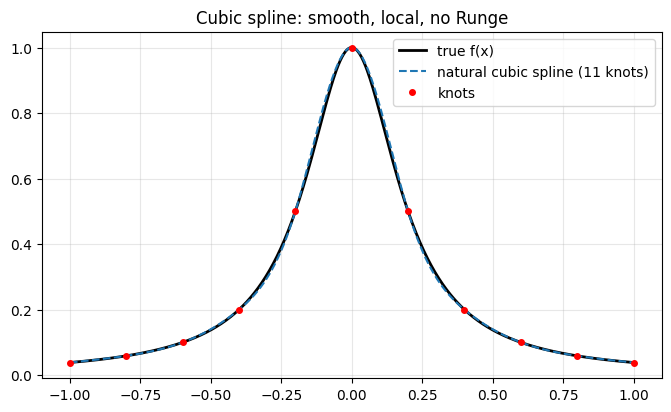

In [7]:
def natural_cubic_spline(x, y):
    n = len(x) - 1
    h = np.diff(x)
    # Tridiagonal system for second derivatives M (natural: M0 = Mn = 0).
    A = np.zeros((n+1, n+1)); rhs = np.zeros(n+1)
    A[0, 0] = 1.0; A[n, n] = 1.0
    for i in range(1, n):
        A[i, i-1] = h[i-1]
        A[i, i]   = 2*(h[i-1] + h[i])
        A[i, i+1] = h[i]
        rhs[i] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])
    M = np.linalg.solve(A, rhs)

    def evaluate(xq):
        xq = np.atleast_1d(xq).astype(float)
        out = np.zeros_like(xq)
        idx = np.clip(np.searchsorted(x, xq) - 1, 0, n-1)
        for k, (xi, i) in enumerate(zip(xq, idx)):
            dx = xi - x[i]; hi = h[i]
            a = (x[i+1]-xi)/hi; b = dx/hi
            out[k] = (a*y[i] + b*y[i+1]
                      + ((a**3 - a)*M[i] + (b**3 - b)*M[i+1]) * hi**2 / 6)
        return out
    return evaluate

xs = np.linspace(-1, 1, 11)
spline = natural_cubic_spline(xs, runge(xs))
fig, ax = plt.subplots()
ax.plot(xfine, runge(xfine), "k", lw=2, label="true f(x)")
ax.plot(xfine, spline(xfine), "--", label="natural cubic spline (11 knots)")
ax.plot(xs, runge(xs), "ro", ms=4, label="knots")
ax.set_title("Cubic spline: smooth, local, no Runge"); ax.legend(); plt.show()


## 5. Least-squares approximation

When data is noisy or we want a *low-degree* trend through *many* points, we drop the interpolation requirement and minimize the squared residual

$$ \min_{c} \|V c - y\|_2^2, $$

where $V$ is the **Vandermonde** design matrix. The normal equations $V^\top V c = V^\top y$ give the classic solution — but $V^\top V$ squares the condition number, so for anything beyond low degree one should use a QR factorization (Week 6 territory) instead.


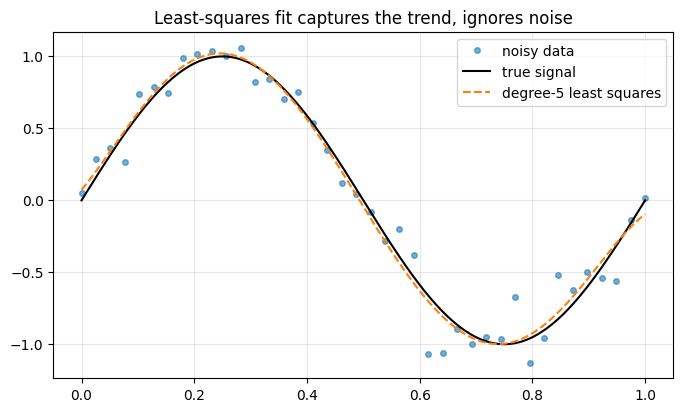

kappa(V)      : 3482.968340390914
kappa(V^T V)  : 12131068.460278971   <- squared! use QR for high degree


In [8]:
def polyfit_normal(x, y, degree):
    V = np.vander(x, degree+1, increasing=True)   # design matrix
    # Solve normal equations (illustrative; QR is preferable for stability).
    return np.linalg.solve(V.T @ V, V.T @ y)

rng = np.random.default_rng(1)
xdata = np.linspace(0, 1, 40)
ytrue = np.sin(2*np.pi*xdata)
ynoisy = ytrue + 0.15*rng.standard_normal(xdata.size)

c = polyfit_normal(xdata, ynoisy, 5)
xeval = np.linspace(0, 1, 200)
yeval = np.vander(xeval, 6, increasing=True) @ c

fig, ax = plt.subplots()
ax.plot(xdata, ynoisy, "o", ms=4, alpha=0.6, label="noisy data")
ax.plot(xeval, np.sin(2*np.pi*xeval), "k", label="true signal")
ax.plot(xeval, yeval, "--", label="degree-5 least squares")
ax.set_title("Least-squares fit captures the trend, ignores noise"); ax.legend(); plt.show()

# Condition-number warning:
V = np.vander(xdata, 6, increasing=True)
print("kappa(V)      :", np.linalg.cond(V))
print("kappa(V^T V)  :", np.linalg.cond(V.T @ V), "  <- squared! use QR for high degree")


## Summary

- Lagrange and Newton forms give the **same unique** interpolating polynomial; Newton's form updates cheaply.
- The **Runge phenomenon** makes high-degree equispaced interpolation diverge — **Chebyshev nodes** restore convergence.
- **Cubic splines** are the practical default: smooth, local, oscillation-free.
- **Least squares** trades exact fit for noise robustness; the normal equations square $\kappa$, so prefer QR for stability.

---

## Exercises

**1. (Barycentric form.)** Implement the *barycentric* Lagrange formula, which precomputes weights and evaluates in $\mathcal{O}(n)$. Verify it matches your $\mathcal{O}(n^2)$ version and is far more stable at high degree.

**2. (Lebesgue constant.)** Numerically estimate the Lebesgue constant $\Lambda_n = \max_x \sum_i |\ell_i(x)|$ for equispaced vs. Chebyshev nodes, and relate its growth to the Runge phenomenon.

**3. (Clamped spline.)** Extend your spline to the *clamped* boundary condition (specified end slopes). Compare its behavior to the natural spline near the endpoints.

**4. (Hermite interpolation.)** Build a cubic Hermite interpolant that matches both values *and* derivatives at two points. Use it to interpolate $\sin x$ and measure the error.

**5. (Overfitting curve.)** For the noisy sine data, plot training error and a held-out test error as a function of polynomial degree (1 to 15). Identify the degree where overfitting begins and connect it to the conditioning warning above.
